In [24]:
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from groq import Groq
import base64
load_dotenv()

True

In [6]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)
prompt = "HI"

In [7]:
response = llm.invoke(prompt)

print(response.content)

Hello! How can I help you today?


In [11]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from io import BytesIO

In [17]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=os.getenv("GEMINI_API_KEY_02")
)

In [50]:
with open("car_01.jpg", "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode()

print("Length:", len(image_base64))
print(image_base64[:100])

Length: 762376
/9j/4AAQSkZJRgABAQEAYABgAAD/4QBERXhpZgAATU0AKgAAAAgAAgEOAAIAAAAHAAAAJpybAAEAAAAOAAAALgAAAAAwNS5qcGcA


In [52]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "give me the details about in the image and the number plate details, context should be in 15 words"
        },
        {
            "type": "image_url",
            "image_url": f"data:image/jpeg;base64,{image_base64}"
        }
    ]
)

In [53]:
response = llm.invoke([message])

print(response.content)

Silver Skoda leads a convoy on a winding road. Number plate: IND MH20DV2366.


TEXT TO IMAGE

In [26]:
from huggingface_hub import InferenceClient

In [27]:
client = InferenceClient(
    api_key=os.getenv("HF_Token")
)

In [36]:
prompt = """ 
    Modern Indian village house, contemporary architecture blended with traditional rural design, sloped tiled roof, natural stone walls, wooden accents, open verandah, landscaped garden, surrounded by green fields and palm trees, realistic architectural rendering, warm evening sunlight, photorealistic, ultra detailed, 512px quality, architectural visualization, cinematic composition
"""


In [37]:
image = client.text_to_image(
    prompt,
    model="black-forest-labs/FLUX.1-schnell"
)

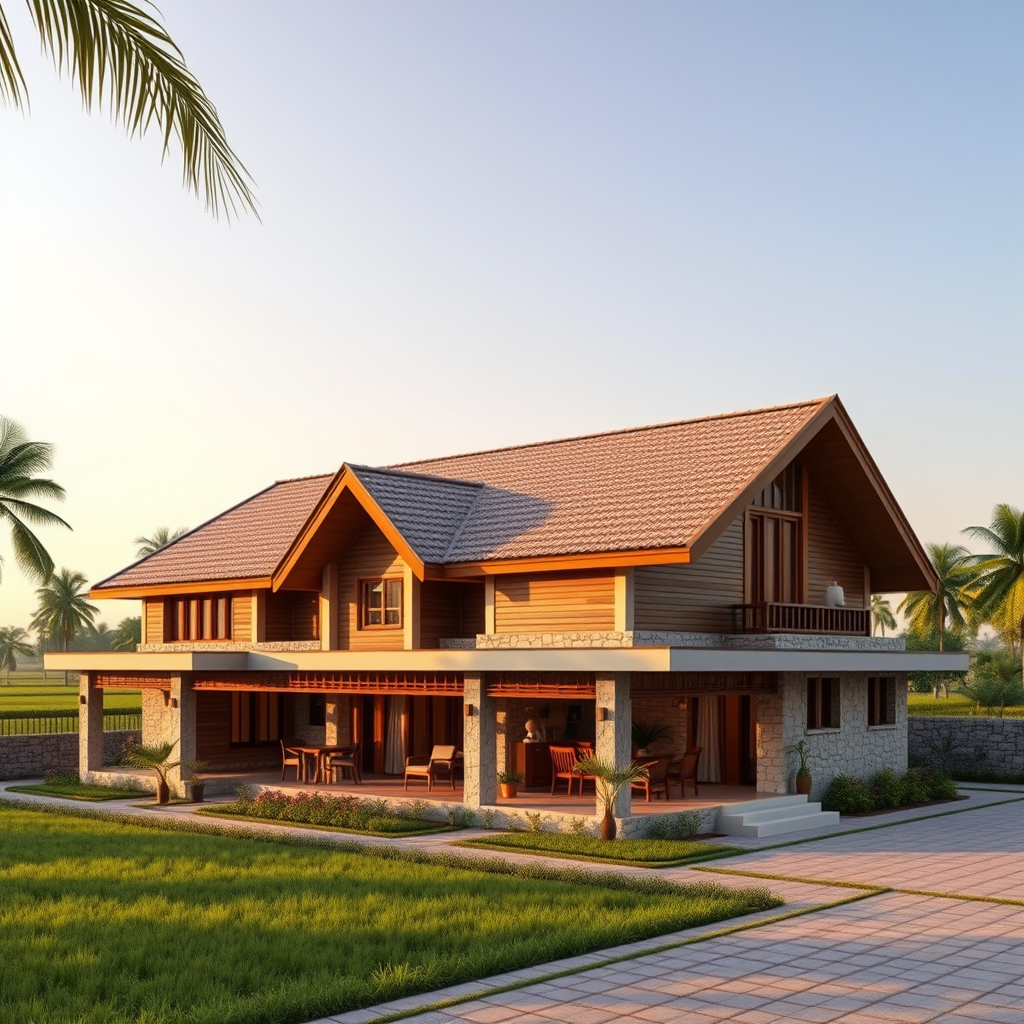

In [38]:
image.save("house.jpg")
image

TEXT TO AUDIO

In [45]:
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

In [ ]:
speech_file_path = "output_audio.wav" 
model = "canopylabs/orpheus-v1-english"
voice = "troy"
text = "Hello, Welcome to AI world.Let me give a brief about how my learning going on in the next chapter, Thanks"
response_format = "wav"

response = client.audio.speech.create(
    model=model,
    voice=voice,
    input=text,
    response_format=response_format
)

response.write_to_file(speech_file_path)

AUDIO TO TEXT

In [48]:
with open("output_audio.wav" , "rb") as audio_file:
    trans = client.audio.transcriptions.create(
        file=audio_file,
        model = "whisper-large-v3-turbo"
    )
print(trans.text)

 Hello, welcome to AI world dot. Let me give a brief about how my learning going on in the next chapter.
